# Heart Disease Risk Prediction

## Proje Amacı

Bu projede çeşitli sağlık göstergeleri kullanılarak bireylerin kalp hastalığı riskini tahmin eden bir sınıflandırma modeli geliştirilmesi amaçlanmıştır.

In [1]:
## Kullanılan Kütüphaneler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
## Veri Setinin Yüklenmesi
df = pd.read_csv("heart_disease_uci.csv")
df = df.drop(columns=["id"])

In [3]:
## İlk Veri İncelemesi
df.head()

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [4]:
## Veri Setinin Genel İncelenmesi
df.shape

(920, 15)

Veri seti toplam 920 gözlem ve 16 değişkenden oluşmaktadır.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    int64  
 1   sex       920 non-null    object 
 2   dataset   920 non-null    object 
 3   cp        920 non-null    object 
 4   trestbps  861 non-null    float64
 5   chol      890 non-null    float64
 6   fbs       830 non-null    object 
 7   restecg   918 non-null    object 
 8   thalch    865 non-null    float64
 9   exang     865 non-null    object 
 10  oldpeak   858 non-null    float64
 11  slope     611 non-null    object 
 12  ca        309 non-null    float64
 13  thal      434 non-null    object 
 14  num       920 non-null    int64  
dtypes: float64(5), int64(2), object(8)
memory usage: 107.9+ KB


## Veri Tipleri ve Eksik Veri Analizi

Veri setinde hem sayısal hem kategorik değişkenler bulunmaktadır.

Özellikle `ca`, `thal` ve `slope` değişkenlerinde yüksek miktarda eksik veri olduğu gözlemlenmiştir.

Makine öğrenmesi modeli kurulmadan önce eksik verilerin uygun şekilde yönetilmesi gerekmektedir.

In [6]:
df.isnull().sum()

age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

## Eksik Veri İncelemesi

Veri setinde bazı değişkenlerde eksik gözlemler bulunduğu görülmüştür.

Özellikle `ca`, `thal` ve `slope` değişkenlerinde yüksek miktarda eksik veri bulunmaktadır.

`ca` değişkenindeki eksik veri oranının oldukça yüksek olması nedeniyle model performansını olumsuz etkileyebileceği düşünülmektedir.

Eksik verilerin yönetimi, veri ön işleme aşamasında ele alınacaktır.

In [7]:
## Eksik Veri Oranları
missing_ratio = (df.isnull().sum() / len(df)) * 100
missing_ratio.sort_values(ascending=False)

ca          66.413043
thal        52.826087
slope       33.586957
fbs          9.782609
oldpeak      6.739130
trestbps     6.413043
thalch       5.978261
exang        5.978261
chol         3.260870
restecg      0.217391
age          0.000000
sex          0.000000
dataset      0.000000
cp           0.000000
num          0.000000
dtype: float64

## Eksik Veri Oranlarının Değerlendirilmesi

Eksik veri oranları incelendiğinde `ca` ve `thal` değişkenlerinde oldukça yüksek seviyede eksik gözlem bulunduğu görülmüştür.

Bu değişkenlerdeki eksik veri oranının %50’nin üzerinde olması nedeniyle veri kalitesini olumsuz etkileyebileceği düşünülmüştür.

Bu nedenle ilgili değişkenlerin modelleme aşamasından çıkarılması planlanmıştır.

In [8]:
## Yüksek Oranda Eksik Veri İçeren Değişkenlerin Kaldırılması
df = df.drop(columns=["ca", "thal", "slope"])

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    int64  
 1   sex       920 non-null    object 
 2   dataset   920 non-null    object 
 3   cp        920 non-null    object 
 4   trestbps  861 non-null    float64
 5   chol      890 non-null    float64
 6   fbs       830 non-null    object 
 7   restecg   918 non-null    object 
 8   thalch    865 non-null    float64
 9   exang     865 non-null    object 
 10  oldpeak   858 non-null    float64
 11  num       920 non-null    int64  
dtypes: float64(4), int64(2), object(6)
memory usage: 86.4+ KB


In [10]:
import warnings
warnings.filterwarnings("ignore")

In [11]:
## Sayısal Eksik Verilerin Doldurulması
numerical_columns = ["trestbps", "chol", "thalch", "oldpeak"]

for col in numerical_columns:
    df[col] = df[col].fillna(df[col].median())

In [12]:
## Kategorik Eksik Verilerin Doldurulması
categorical_columns = ["fbs", "restecg", "exang"]

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0]).infer_objects(copy=False)

In [13]:
df.isnull().sum()

age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
num         0
dtype: int64

## Eksik Veri Analizi ve Veri Ön İşleme

Veri setinde yapılan incelemeler sonucunda bazı değişkenlerde eksik gözlemler bulunduğu tespit edilmiştir.

Özellikle `ca`, `thal` ve `slope` değişkenlerinde yüksek oranda eksik veri bulunduğu gözlemlenmiştir. Eksik veri oranlarının oldukça yüksek olması nedeniyle bu değişkenlerin modelleme sürecinden çıkarılmasına karar verilmiştir.

Sayısal değişkenlerde bulunan eksik veriler, aykırı değerlere karşı daha dayanıklı olması nedeniyle medyan yöntemi kullanılarak doldurulmuştur.

Kategorik değişkenlerdeki eksik gözlemler ise mod (en sık görülen değer) yöntemi ile tamamlanmıştır.

Veri ön işleme sürecinin ardından veri setindeki eksik gözlemler tamamen giderilmiştir.

In [14]:
## Hedef Değişkenin Düzenlenmesi
df["num"] = df["num"].apply(lambda x: 0 if x == 0 else 1)

In [15]:
df["num"].value_counts()

num
1    509
0    411
Name: count, dtype: int64

## Hedef Değişken Analizi

`num` değişkeni ikili sınıflandırma problemine uygun hale getirilmiştir.

0 değeri kalp hastalığı bulunmayan bireyleri, 1 değeri ise kalp hastalığı bulunan bireyleri temsil etmektedir.

Veri setindeki sınıf dağılımı incelendiğinde veri yapısının dengeli olduğu gözlemlenmiştir.

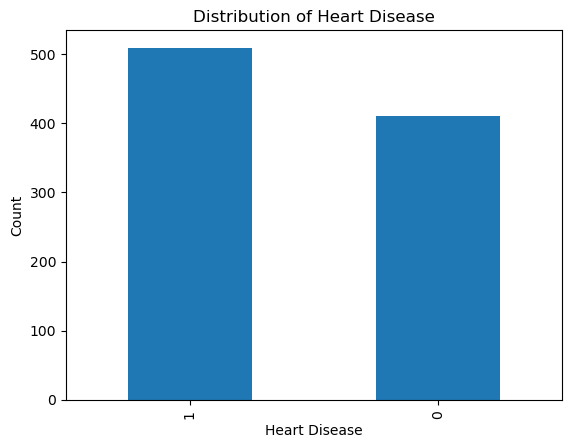

In [16]:
## Hedef Değişken Dağılımı
df["num"].value_counts().plot(kind="bar")

plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.title("Distribution of Heart Disease")
plt.show()

Veri setindeki kalp hastalığı dağılımı incelendiğinde hastalığa sahip birey sayısının hastalığı bulunmayan birey sayısından biraz daha fazla olduğu görülmektedir.

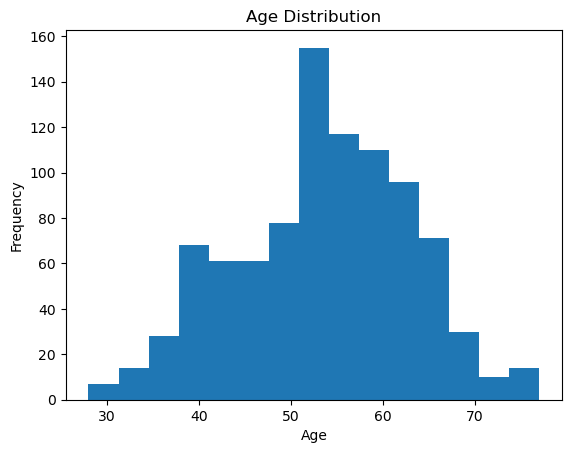

In [17]:
## Yaş Dağılımının İncelenmesi
plt.hist(df["age"], bins=15)

plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")

plt.show()

Yaş dağılımı incelendiğinde veri setindeki bireylerin büyük kısmının orta yaş ve üzeri bireylerden oluştuğu gözlemlenmiştir.

Özellikle 50-60 yaş aralığında yoğunluk olduğu dikkat çekmektedir.

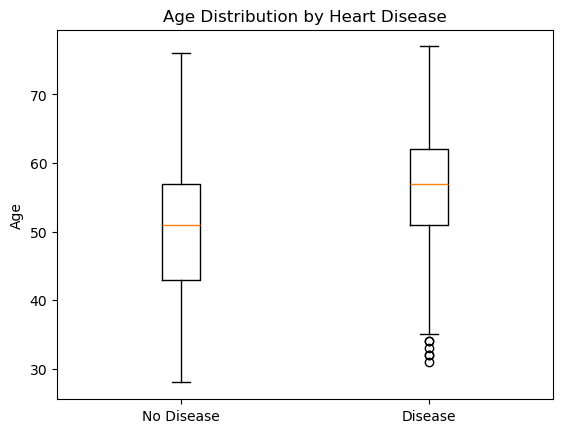

In [18]:
## Yaş ve Kalp Hastalığı İlişkisi
plt.boxplot(
    [df[df["num"] == 0]["age"],
     df[df["num"] == 1]["age"]],
    labels=["No Disease", "Disease"]
)

plt.ylabel("Age")
plt.title("Age Distribution by Heart Disease")

plt.show()

Yaş dağılımları incelendiğinde kalp hastalığı bulunan bireylerin yaş değerlerinin genel olarak daha yüksek olduğu gözlemlenmiştir.

Bu durum yaş değişkeninin kalp hastalığı riski ile ilişkili olabileceğini göstermektedir.

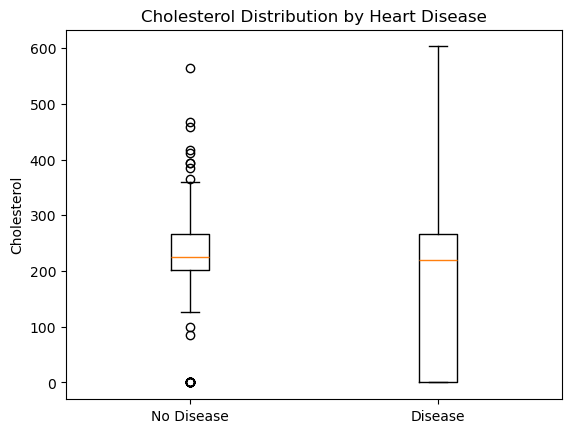

In [19]:
## Kolesterol ve Kalp Hastalığı İlişkisi
plt.boxplot(
    [df[df["num"] == 0]["chol"],
     df[df["num"] == 1]["chol"]],
    labels=["No Disease", "Disease"]
)

plt.ylabel("Cholesterol")
plt.title("Cholesterol Distribution by Heart Disease")

plt.show()

In [20]:
## Kolesterol Değişkenindeki Mantıksız Değerlerin İncelenmesi
(df["chol"] == 0).sum()

df["chol"] = df["chol"].replace(0, np.nan)

df["chol"] = df["chol"].fillna(df["chol"].median())

Kolesterol değişkeninde gerçek hayatta mümkün olmayan `0` değerleri tespit edilmiştir.

Bu değerler eksik veri olarak değerlendirilmiş ve medyan yöntemi ile doldurulmuştur.

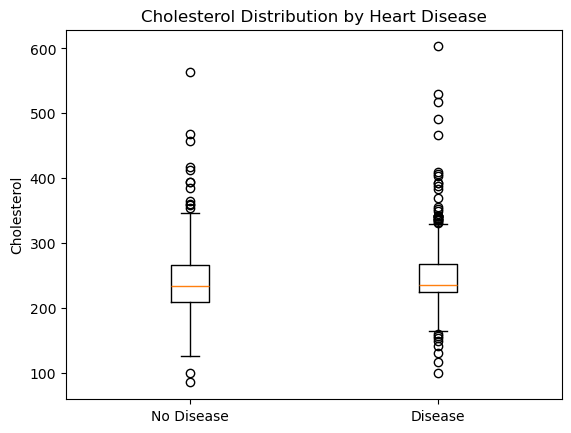

In [21]:
## Güncellenmiş Kolesterol Dağılımı
plt.boxplot(
    [df[df["num"] == 0]["chol"],
     df[df["num"] == 1]["chol"]],
    labels=["No Disease", "Disease"]
)

plt.ylabel("Cholesterol")
plt.title("Cholesterol Distribution by Heart Disease")

plt.show()

In [22]:
## Cinsiyet ve Kalp Hastalığı İlişkisi
pd.crosstab(df["sex"], df["num"])

num,0,1
sex,,
Female,144,50
Male,267,459


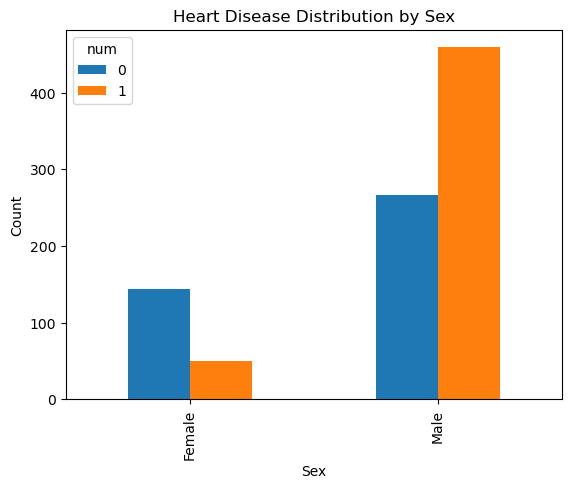

In [23]:
pd.crosstab(df["sex"], df["num"]).plot(kind="bar")

plt.xlabel("Sex")
plt.ylabel("Count")
plt.title("Heart Disease Distribution by Sex")

plt.show()

Cinsiyet dağılımı incelendiğinde kalp hastalığı görülen bireylerin erkeklerde daha fazla olduğu gözlemlenmiştir.

Ancak veri setindeki cinsiyet dağılımının tamamen dengeli olmadığı da dikkat çekmektedir.

## Kategorik Değişkenlerin Dönüştürülmesi

Makine öğrenmesi algoritmaları kategorik veriler üzerinde doğrudan işlem yapamadığı için kategorik değişkenler sayısal formata dönüştürülmüştür.

In [24]:
df_encoded = pd.get_dummies(df, drop_first=True)

## Korelasyon Analizi

Değişkenler arasındaki ilişkileri incelemek amacıyla korelasyon matrisi oluşturulmuştur.

In [25]:
corr_matrix = df_encoded.corr()

In [26]:
corr_matrix.head()

,age,trestbps,chol,fbs,thalch,exang,oldpeak,num,sex_Male,dataset_Hungary,dataset_Switzerland,dataset_VA Long Beach,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality
age,1.000000,0.230784,0.065451,0.219915,-0.349715,0.160910,0.233550,0.282700,0.056889,-0.407613,0.075329,0.326713,-0.218902,-0.010060,0.032032,-0.231296,0.137748
trestbps,0.230784,1.000000,0.075414,0.143709,-0.104747,0.153835,0.161217,0.101273,-0.002145,0.021795,-0.038183,0.020416,-0.043835,-0.041872,0.044407,-0.109005,0.075605
chol,0.065451,0.075414,1.000000,0.051814,-0.016220,0.072250,0.049270,0.084140,-0.101088,0.066250,-0.060688,-0.059976,-0.012083,-0.062980,-0.049928,-0.042609,-0.041382
fbs,0.219915,0.143709,0.051814,1.000000,-0.026472,-0.003475,0.034112,0.108071,0.075370,-0.156489,-0.120305,0.280445,-0.062963,0.002931,0.043298,-0.167536,0.124189
thalch,-0.349715,-0.104747,-0.016220,-0.026472,1.000000,-0.354173,-0.149401,-0.381864,-0.174590,0.034918,-0.249873,-0.216790,0.244578,0.140007,0.100444,0.011757,-0.136345


In [27]:
import seaborn as sns

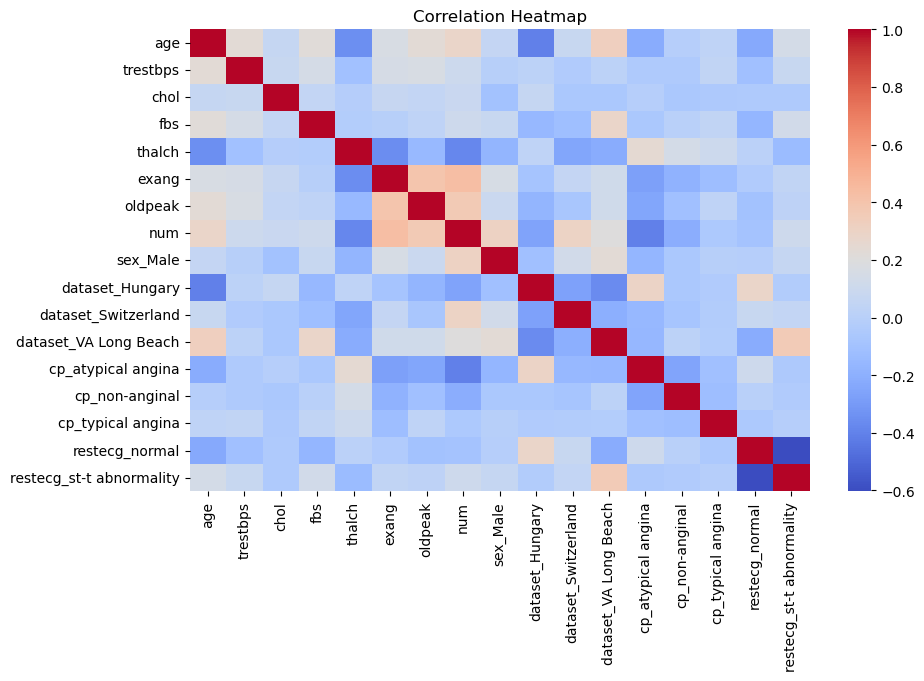

In [28]:
## Korelasyon Heatmap Görselleştirmesi
plt.figure(figsize=(10,6))

sns.heatmap(corr_matrix,
            cmap="coolwarm",
            annot=False)

plt.title("Correlation Heatmap")

plt.show()

## Korelasyon Analizi Sonuçları

Korelasyon heatmap incelendiğinde bazı değişkenlerin kalp hastalığı değişkeni ile daha belirgin ilişkilere sahip olduğu gözlemlenmiştir.

Özellikle `exang` ve `oldpeak` değişkenlerinin hedef değişken ile pozitif ilişki gösterdiği dikkat çekmektedir.

`thalch` değişkeninin ise hedef değişken ile negatif yönlü ilişki gösterdiği görülmektedir.

Genel olarak değişkenler arasında çok yüksek korelasyon değerleri bulunmaması, veri setinde ciddi düzeyde doğrusal bağımlılık problemi olmadığını düşündürmektedir.

## Özellik ve Hedef Değişkenlerin Ayrılması

In [29]:
X = df_encoded.drop("num", axis=1)
y = df_encoded["num"]

In [30]:
X.head()

,age,trestbps,chol,fbs,thalch,exang,oldpeak,sex_Male,dataset_Hungary,dataset_Switzerland,dataset_VA Long Beach,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality
0,63,145.0,233.0,True,150.0,False,2.3,True,False,False,False,False,False,True,False,False
1,67,160.0,286.0,False,108.0,True,1.5,True,False,False,False,False,False,False,False,False
2,67,120.0,229.0,False,129.0,True,2.6,True,False,False,False,False,False,False,False,False
3,37,130.0,250.0,False,187.0,False,3.5,True,False,False,False,False,True,False,True,False
4,41,130.0,204.0,False,172.0,False,1.4,False,False,False,False,True,False,False,False,False


In [31]:
y.head()

0    0
1    1
2    1
3    0
4    0
Name: num, dtype: int64

In [32]:
## Eğitim ve Test Verisinin Ayrılması
from sklearn.model_selection import train_test_split

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [34]:
X_train.shape, X_test.shape

((736, 16), (184, 16))

In [35]:
y_train.shape, y_test.shape

((736,), (184,))

## Logistic Regression Modelinin Kurulması

In [36]:
from sklearn.linear_model import LogisticRegression

In [37]:
model = LogisticRegression(max_iter=1000)

In [50]:
model.fit(X_train, y_train);

In [51]:
y_pred = model.predict(X_test)
y_pred[:10]

array([0, 1, 1, 1, 1, 1, 0, 1, 0, 1])

## Model Performansının Değerlendirilmesi
Logistic Regression modeli test verisi üzerinde değerlendirilmiştir.

In [40]:
from sklearn.metrics import accuracy_score

In [41]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)


Accuracy: 0.8369565217391305


Modelin doğruluk oranı incelendiğinde test verisi üzerinde başarılı sonuçlar verdiği gözlemlenmiştir.

## Confusion Matrix Analizi

In [42]:
from sklearn.metrics import confusion_matrix

In [43]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[64 18]
 [12 90]]


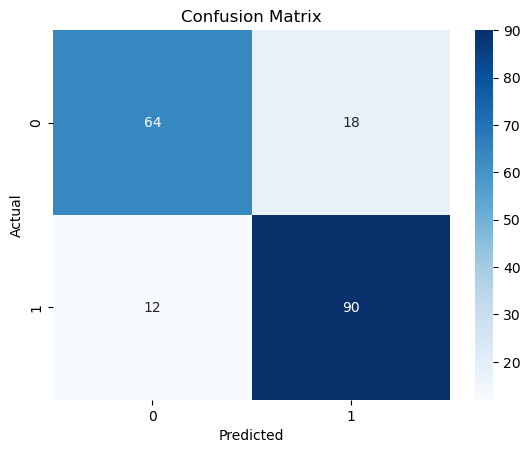

In [44]:
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

## Confusion Matrix Sonuçlarının Değerlendirilmesi

Confusion matrix sonuçları incelendiğinde modelin kalp hastalığı bulunan bireyleri büyük ölçüde doğru tahmin ettiği görülmektedir.

Model, 89 hastayı doğru şekilde sınıflandırırken 20 hastayı yanlış şekilde sağlıklı olarak tahmin etmiştir.

Bunun yanında 63 sağlıklı birey doğru tahmin edilirken 12 sağlıklı birey yanlış şekilde hasta olarak sınıflandırılmıştır.

Genel olarak modelin başarılı performans gösterdiği ancak bazı yanlış sınıflandırmaların bulunduğu gözlemlenmiştir.

## Classification Report Analizi

In [45]:
from sklearn.metrics import classification_report

In [46]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.78      0.81        82
           1       0.83      0.88      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.83      0.83       184
weighted avg       0.84      0.84      0.84       184



## Classification Report Sonuçlarının Değerlendirilmesi

Classification report sonuçları incelendiğinde Logistic Regression modelinin test verisi üzerinde başarılı performans gösterdiği görülmektedir.

Modelin genel doğruluk oranı %83 olarak elde edilmiştir.

Kalp hastalığı bulunan bireyler için precision değerinin yüksek olması, modelin pozitif tahminlerde başarılı olduğunu göstermektedir.

Recall değerinin %82 olması ise modelin gerçek hastaların büyük bölümünü doğru şekilde tespit edebildiğini göstermektedir.

F1-score değerleri incelendiğinde modelin precision ve recall arasında dengeli bir performans sergilediği görülmektedir.

## Özellik Katsayılarının İncelenmesi

In [47]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients

,Feature,Coefficient
0,age,0.027936
1,trestbps,0.003393
2,chol,0.004814
3,fbs,0.412251
4,thalch,-0.012436
5,exang,1.010113
6,oldpeak,0.572469
7,sex_Male,1.252312
8,dataset_Hungary,-0.132650
9,dataset_Switzerland,2.212374


In [48]:
coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

coefficients

,Feature,Coefficient
9,dataset_Switzerland,2.212374
7,sex_Male,1.252312
5,exang,1.010113
6,oldpeak,0.572469
3,fbs,0.412251
10,dataset_VA Long Beach,0.381183
0,age,0.027936
2,chol,0.004814
1,trestbps,0.003393
4,thalch,-0.012436


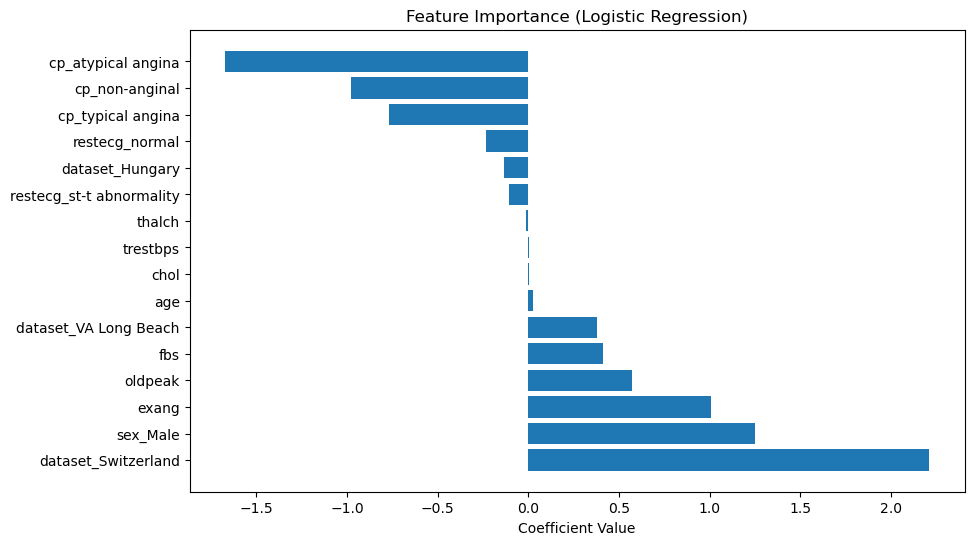

In [49]:
plt.figure(figsize=(10,6))

plt.barh(
    coefficients["Feature"],
    coefficients["Coefficient"]
)

plt.xlabel("Coefficient Value")
plt.title("Feature Importance (Logistic Regression)")

plt.show()

## Özellik Katsayılarının Değerlendirilmesi

Logistic Regression modeli tarafından öğrenilen katsayılar incelendiğinde bazı değişkenlerin kalp hastalığı tahmini üzerinde daha etkili olduğu görülmektedir.

Özellikle `sex_Male`, `exang` ve `oldpeak` değişkenlerinin pozitif katsayılara sahip olması bu değişkenlerin hastalık riski ile pozitif ilişki gösterebileceğini düşündürmektedir.

`exang` değişkeninin pozitif katsayıya sahip olması, egzersiz sırasında ortaya çıkan göğüs ağrısının kalp hastalığı ile ilişkili olabileceğini göstermektedir.

Benzer şekilde `oldpeak` değişkeninin yüksek katsayıya sahip olması, egzersiz sırasında ST depresyonundaki artışın hastalık riskiyle ilişkili olabileceğini düşündürmektedir.

Bunun yanında `thalch` değişkeninin negatif katsayıya sahip olması maksimum kalp ritmi arttıkça hastalık riskinin azalabileceğini göstermektedir.

Bazı değişkenlerin katsayılarının düşük olması ise model üzerinde daha sınırlı etkiye sahip olduklarını göstermektedir.

## Veri Kaynağı Değişkenleri Hakkında Not

Veri setinde bulunan `dataset_Hungary`, `dataset_Switzerland` ve `dataset_VA Long Beach` gibi değişkenler hastalara ait tıbbi özellikleri değil, verilerin toplandığı kaynakları temsil etmektedir.

Bu değişkenlerin modelde yüksek katsayı değerleri alması, veri kaynakları arasındaki dağılım farklılıklarından kaynaklanıyor olabilir.

Bu nedenle bu sütunların yüksek etkisi doğrudan tıbbi bir anlam taşımayabilir.

# Sonuç

Bu projede kalp hastalığı verileri kullanılarak bir Logistic Regression modeli geliştirilmiştir.

Veri ön işleme, eksik veri yönetimi, keşifsel veri analizi ve model değerlendirme aşamaları gerçekleştirilmiştir.

Model test verisi üzerinde %83 doğruluk oranı elde etmiş ve hastalık tahmini konusunda başarılı sonuçlar göstermiştir.

Sonuçlar, bazı sağlık göstergelerinin kalp hastalığı riski ile ilişkili olabileceğini göstermektedir.